In [1]:
# Repo-root bootstrap: find the directory containing the `llm_perf` package
# (walking up from CWD) and chdir there so paths like "llm_perf/database/..."
# and "assets/..." resolve regardless of where the notebook lives on disk.
import os
from pathlib import Path
_p = Path.cwd()
while not (_p / "llm_perf" / "__init__.py").exists():
    if _p == _p.parent:
        raise RuntimeError("Could not find llm_perf repo root from " + str(Path.cwd()))
    _p = _p.parent
os.chdir(_p)
print("cwd:", Path.cwd())

cwd: /Users/jasonlu/Projects/ai.cluster/llm_perf


# Pareto Frontiers — Collective Algorithm Choice

**Question:** how much does the choice of collective algorithm move the decode Pareto frontier? Three configurations on the same hardware, same model:

1. **Worst-case SW** — pin every collective to *ring*. Maximum α-side cost on AR (`2(G-1)·α`); INC disabled. This is the do-nothing baseline an operator who never tunes the dispatcher would get.
2. **Optimized SW** — let `core/collective_algo_opt.optimize_collective_algorithms` pick the best SW algorithm per (phase × collective) by message-size-aware `min(enumerate_options(...))`. Still no INC. This is the headline benefit of the post-partition SW tuner: ring vs DBT vs hierarchical fall out automatically.
3. **INC** — let the optimizer pick INC where the fabric supports it (NVLS on the NVLink5 inner tier, Quantum SHARP on the IB outer tier — *AR/AG only*; A2A still uses SW pairwise since the sharp_class capability doesn't accelerate it). INC selection is prioritized over SW comparison: when available, it's used unconditionally.

**Setup:** GPT-1.8T MoE @ FP4 on a GB200 NVL576 cluster with NVLS + Quantum SHARP declared (`gb200.nvl576.hierarchical.inc.json`). 2-tier topology — inner `intra-rack-nvswitch` (72 ports, 900 GB/s, α=0.5 μs, sharp_class) and outer `inter-rack-quantum-ib` (8 ports, 400 GB/s, α=2.5 μs, sharp_class). All three sweeps share the same system spec — only the `TuningSpec` algorithm fields and `inc_enabled` flag change. This isolates the algorithm-choice effect from any topology / device differences.

**Why GPT-1.8T MoE on NVL576?** Same model + cluster as the other notebooks (`pareto_basic`, `pareto_vs_scale_up_tier`) so frontiers are directly comparable. With this model the partition enumerator caps `TP ≤ min(n_kv, n_experts) = 16` and `EP ≤ n_experts = 16`, so each *individual* TP / EP / SP collective group stays well within the 72-port NVLink5 inner tier — the multi-tier hierarchical AR / AG branch from PR2 doesn't fire and the comparison is purely *single-tier ring vs DBT vs INC*. The `TP·EP ≤ scale_up=576` cap (tier_idx=1) is the *layout* constraint that lets a partition's combined inner-axes span the full cluster, not a per-collective group size.


## 1. Imports and spec loading

In [2]:
from __future__ import annotations

import math
from copy import deepcopy
from dataclasses import dataclass

import matplotlib.pyplot as plt

from llm_perf import InferenceCalculator
from llm_perf.core.collective_algo_opt import optimize_collective_algorithms
from llm_perf.core.kv_paging_model import KVPagingConfig, compute_kv_paging
from llm_perf.core.memory_model import compute_memory
from llm_perf.io import load_model_spec, load_system_spec, load_tuning_spec
from llm_perf.specs.partition_spec import PartitionSpec

MODEL = "llm_perf/database/model/gpt_1_8t_moe.json"
SYSTEM = "llm_perf/database/system/gb200.nvl576.hierarchical.inc.json"
TUNER = "llm_perf/database/tuner/gpt_1_8t_moe.tuner.json"

S_DECODE = 8192
BPP_FP4 = 0.5

model = load_model_spec(MODEL)
model.bytes_per_param = BPP_FP4
system = load_system_spec(SYSTEM)
tuner_base = load_tuning_spec(TUNER)
tuner_base.S_decode = S_DECODE
tuner_base.B_decode = 1

print(f"Model:  {model.name}  L={model.L}  H={model.H}  n_kv={model.n_kv}  b={model.bytes_per_param}")
print(f"System: {system.name}  N={system.num_devices} GPUs")
tp_chain = system.get_tier_chain('TP')
for t in tp_chain:
    inc_str = f" inc={getattr(t, 'inc', 'none')}" if getattr(t, 'inc', 'none') != 'none' else ''
    print(f"  - tier {t.name:30s} ports={t.ports:3d} BW={t.bw_per_port_GBps:.0f} GB/s α={t.alpha_us:.2f} μs{inc_str}")

Model:  GPT-1.8T-MoE  L=120  H=20480  n_kv=16  b=0.5
System: gb200_nvl576_hierarchical_inc  N=576 GPUs
  - tier intra-rack-nvswitch            ports= 72 BW=900 GB/s α=0.50 μs inc=sharp_class
  - tier inter-rack-quantum-ib          ports=  8 BW=400 GB/s α=2.50 μs inc=sharp_class


## 2. Partition enumeration

Same `llm_perf.utils.enumerate_partitions` as `pareto_basic`, with two non-default settings:

1. **`PP ≤ 8`** — operational PP cap (matches `pareto_basic`). The library default is 32; this notebook pins `PP_MAX=8` to match the realistic deployment regime where pipeline bubble cost / latency budget / microbatch-floor make deeper PP impractical. Raise `PP_MAX` to study the unbounded case.
2. **`scale_up_tier_index=1`** — the `TP·EP ≤ scale_up_domain` cap reaches the full cluster (576 = 72×8 = inner NVL5 × outer IB) instead of just one rack. This is intentional: we want the algorithm-choice comparison to exercise cross-rack collectives where INC's BW-eff doubling matters most.

Live constraints (printed by `describe_constraints` below):

- `PP ≤ 8` (ladder; capped here)
- `TP ≤ min(n_kv=16, n_experts=16) = 16` (powers-of-2 ladder)
- `EP ≤ n_experts = 16` (powers-of-2 ladder)
- `TP·EP ≤ scale_up=576` (cluster-wide; tier_idx=1)
- `SP` sweeps `[1, 2, 4, 8, 16, 32, 64]`
- `PP · TP · EP · SP ≤ num_devices = 576`


In [3]:
PP_MAX = 8   # Operational cap; raise to 32 to match unbounded-PP analysis.

from llm_perf.utils import (
    enumerate_partitions as _enumerate_partitions,
    describe_constraints,
)


def enumerate_partitions(num_devices: int) -> list[PartitionSpec]:
    """Local shim around llm_perf.utils.enumerate_partitions; pins (model, system, pp_max).

    Constraints applied: PP <= PP_MAX (set above; default 8 here, vs the
    library's 32);  TP <= min(n_kv, n_experts); EP <= n_experts (or 1 for dense);
    TP*EP <= scale_up_domain_size(system, tier_idx=1) = 72*8 = 576
    (full cluster — allow partitions that span the IB tier so the
    algorithm-choice comparison ring vs sw_opt vs INC actually exercises
    cross-rack collectives); SP <= 64 (ladder-based);
    PP*TP*EP*SP <= num_devices.
    See `llm_perf/utils/partition_enum.py` for the full derivation.
    """
    return _enumerate_partitions(model, system, num_devices=num_devices,
                                  pp_max=PP_MAX, scale_up_tier_index=1)


print(describe_constraints(model, system, pp_max=PP_MAX, scale_up_tier_index=1))

partitions = enumerate_partitions(system.num_devices)
print(f"Valid partitions on {system.num_devices} GPUs: {len(partitions)}")
print("First 6:", [f"PP={p.PP} TP={p.TP} EP={p.EP} SP={p.SP}" for p in partitions[:6]])


PP ≤ 8; TP ≤ min(n_kv=16, n_experts=16) = 16; EP ≤ n_experts=16; TP·EP ≤ scale_up=576 (tier_idx=1)
Valid partitions on 576 GPUs: 687
First 6: ['PP=1 TP=1 EP=1 SP=1', 'PP=1 TP=1 EP=1 SP=2', 'PP=1 TP=1 EP=1 SP=4', 'PP=1 TP=1 EP=1 SP=8', 'PP=1 TP=1 EP=1 SP=16', 'PP=1 TP=1 EP=1 SP=32']


## 3. Sweep parameterized by collective-algorithm mode

One sweep function covers all three configs. The mode selects:

| Mode | tp/ep_algorithm_{decode,prefill} | inc_enabled |
|---|---|---|
| `worst` | `"ring"` | `False` |
| `sw_opt` | `"auto"` | `False` |
| `inc` | `"auto"` | `True` |

For `auto` modes, the optimizer is called per `(partition, B)` because message size depends on `B` and the optimizer's choice (ring vs tree at small M, INC where eligible) reflects that.


In [4]:
@dataclass
class Point:
    partition: PartitionSpec
    B: int
    tput_per_gpu: float
    interactivity: float
    TPOT_ms: float

    @property
    def part_label(self) -> str:
        p = self.partition
        return f"PP={p.PP} TP={p.TP} EP={p.EP} SP={p.SP}"


def make_tuner(mode: str, base):
    t = deepcopy(base)
    if mode == "worst":
        t.tp_algorithm_decode = t.tp_algorithm_prefill = "ring"
        t.ep_algorithm_decode = t.ep_algorithm_prefill = "ring"
        t.inc_enabled = False
    elif mode == "sw_opt":
        t.tp_algorithm_decode = t.tp_algorithm_prefill = "auto"
        t.ep_algorithm_decode = t.ep_algorithm_prefill = "auto"
        t.inc_enabled = False
    elif mode == "inc":
        t.tp_algorithm_decode = t.tp_algorithm_prefill = "auto"
        t.ep_algorithm_decode = t.ep_algorithm_prefill = "auto"
        t.inc_enabled = True
    else:
        raise ValueError(f"unknown mode {mode!r}")
    return t


def log_spaced_batch_sizes(b_max: int) -> list[int]:
    if b_max <= 1:
        return [1]
    n = max(int(math.log10(b_max) * 10), 16)
    raw = {1, b_max}
    for i in range(n + 1):
        raw.add(max(1, int(round(10 ** (i * math.log10(b_max) / n)))))
    p = 1
    while p <= b_max:
        raw.add(p)
        p *= 2
    return sorted(raw)


def sweep(mode: str) -> list[Point]:
    base = make_tuner(mode, tuner_base)
    pts: list[Point] = []
    for partition in partitions:
        try:
            mem = compute_memory(model, system, partition, base)
        except Exception:
            continue
        paging = KVPagingConfig(block_size=16, beam_width=1, system_overhead_GB=1.5)
        kv = compute_kv_paging(model, system, partition, base, mem, paging)
        b_max = int(kv.max_sequences)
        if b_max < 1:
            continue
        for B in log_spaced_batch_sizes(b_max):
            tuner = deepcopy(base)
            tuner.B_decode = B
            # Resolve `auto` per (partition, B) since message size depends on B.
            if mode != "worst":
                tuner = optimize_collective_algorithms(model, partition, system, tuner)
            try:
                r = InferenceCalculator(model, system, partition, tuner).run()
            except Exception:
                continue
            if r.latency.TPOT <= 0:
                continue
            pts.append(Point(
                partition=partition, B=B,
                tput_per_gpu=r.latency.TTPS / system.num_devices,
                interactivity=1.0 / r.latency.TPOT,
                TPOT_ms=r.latency.TPOT * 1e3,
            ))
    return pts


def pareto_frontier(points: list[Point]) -> list[Point]:
    sorted_pts = sorted(points, key=lambda p: (-p.tput_per_gpu, -p.interactivity))
    frontier: list[Point] = []
    best_interact = -math.inf
    for p in sorted_pts:
        if p.interactivity > best_interact + 1e-9:
            frontier.append(p)
            best_interact = p.interactivity
    frontier.sort(key=lambda p: p.tput_per_gpu)
    return frontier


MODES = ["worst", "sw_opt", "inc"]
all_points = {m: sweep(m) for m in MODES}
frontiers = {m: pareto_frontier(all_points[m]) for m in MODES}

for m in MODES:
    fr = frontiers[m]
    print(f"  {m:8s}  cloud={len(all_points[m]):4d}  frontier={len(fr):3d}")

  worst     cloud=22432  frontier= 55
  sw_opt    cloud=22432  frontier= 57
  inc       cloud=22432  frontier= 56


## 4. Plot — three frontiers overlaid


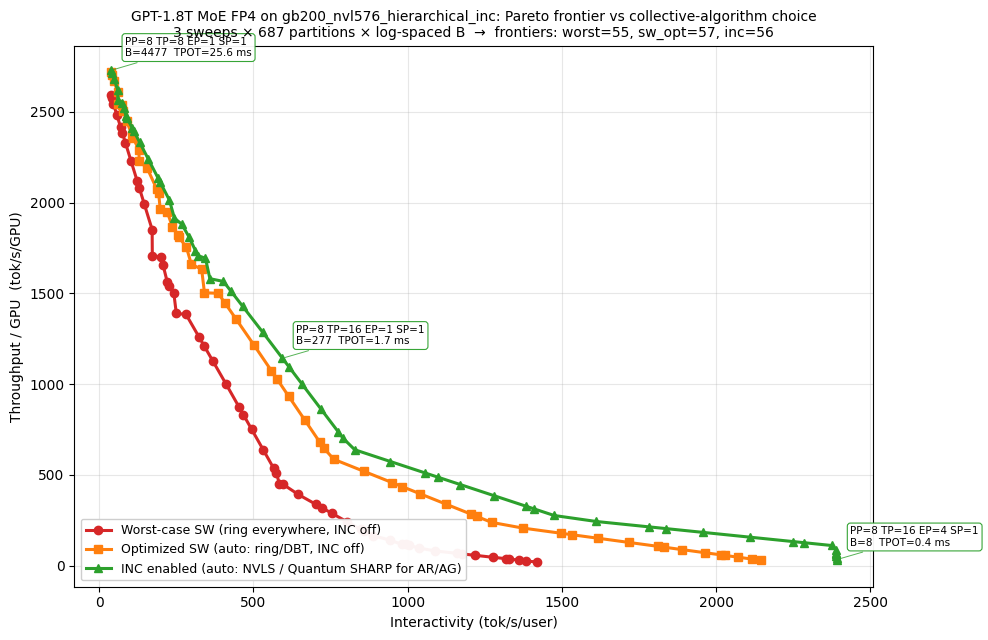

In [5]:
fig, ax = plt.subplots(figsize=(10, 6.5))

STYLES = {
    "worst":  dict(color="tab:red",    lw=2.2, ms=6, marker="o", label="Worst-case SW (ring everywhere, INC off)"),
    "sw_opt": dict(color="tab:orange", lw=2.2, ms=6, marker="s", label="Optimized SW (auto: ring/DBT, INC off)"),
    "inc":    dict(color="tab:green",  lw=2.2, ms=6, marker="^", label="INC enabled (auto: NVLS / Quantum SHARP for AR/AG)"),
}

for m in MODES:
    fr = frontiers[m]
    if not fr:
        continue
    xs = [p.interactivity for p in fr]
    ys = [p.tput_per_gpu for p in fr]
    ax.plot(xs, ys, "-", **STYLES[m])

# Annotate corners on the INC frontier (the headline curve).
fr_inc = frontiers["inc"]
if len(fr_inc) >= 3:
    idxs = [0, len(fr_inc) // 2, len(fr_inc) - 1]
    for i in idxs:
        p = fr_inc[i]
        ax.annotate(
            f"{p.part_label}\nB={p.B}  TPOT={p.TPOT_ms:.1f} ms",
            xy=(p.interactivity, p.tput_per_gpu),
            xytext=(10, 10), textcoords="offset points",
            fontsize=7.5, ha="left", color="black",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="tab:green", alpha=0.95, lw=0.8),
            arrowprops=dict(arrowstyle="-", color="tab:green", lw=0.7, alpha=0.8),
        )

ax.set_xscale("linear")
ax.set_yscale("linear")
ax.set_xlabel("Interactivity (tok/s/user)")
ax.set_ylabel("Throughput / GPU  (tok/s/GPU)")
ax.set_title(
    f"GPT-1.8T MoE FP4 on {system.name}: Pareto frontier vs collective-algorithm choice\n"
    f"3 sweeps × {len(partitions)} partitions × log-spaced B  →  "
    f"frontiers: worst={len(frontiers['worst'])}, sw_opt={len(frontiers['sw_opt'])}, "
    f"inc={len(frontiers['inc'])}",
    fontsize=10,
)
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="lower left", fontsize=9, framealpha=0.95)
fig.tight_layout()
fig.savefig("assets/pareto_collective_algorithms.png", dpi=130, bbox_inches="tight")
plt.show()

## 5. Per-corner comparison table

For a few representative corners (lowest-throughput high-interactivity, mid-frontier, highest-throughput low-interactivity), what does each mode pick and how does TPOT compare?

In [6]:
def at_interactivity(fr, target_interact):
    if not fr:
        return None
    return min(fr, key=lambda p: abs(math.log(p.interactivity / target_interact)))


if frontiers["inc"]:
    inc_xs = [p.interactivity for p in frontiers["inc"]]
    targets = [
        ("high-interactivity", max(inc_xs)),
        ("mid frontier",       (min(inc_xs) * max(inc_xs)) ** 0.5),
        ("high-throughput",    min(inc_xs)),
    ]
    print(f"{'corner':22s} {'mode':10s} {'partition':24s} {'B':>5s} {'TPOT (ms)':>10s} {'tput/GPU':>10s}")
    print("-" * 86)
    for label, tgt in targets:
        for m in MODES:
            p = at_interactivity(frontiers[m], tgt)
            if p is None:
                continue
            print(f"{label:22s} {m:10s} {p.part_label:24s} {p.B:>5d} {p.TPOT_ms:>10.2f} {p.tput_per_gpu:>10.2f}")
        print()

corner                 mode       partition                    B  TPOT (ms)   tput/GPU
--------------------------------------------------------------------------------------
high-interactivity     worst      PP=8 TP=8 EP=8 SP=1          8       0.70      19.73
high-interactivity     sw_opt     PP=8 TP=16 EP=4 SP=1         8       0.47      29.80
high-interactivity     inc        PP=8 TP=16 EP=4 SP=1         8       0.42      33.20

mid frontier           worst      PP=8 TP=16 EP=1 SP=1       560       3.09    1258.73
mid frontier           sw_opt     PP=6 TP=16 EP=1 SP=1       534       3.35    1660.25
mid frontier           inc        PP=6 TP=16 EP=1 SP=1       534       3.21    1734.81

high-throughput        worst      PP=8 TP=8 EP=1 SP=1       4096      24.86    2574.77
high-throughput        sw_opt     PP=8 TP=8 EP=1 SP=1       4477      25.72    2719.89
high-throughput        inc        PP=8 TP=8 EP=1 SP=1       4477      25.64    2728.16



## 6. Takeaways

- **PP=8 cap activates EP as a frontier lever.** Under the unbounded-PP analysis the dominant winners were PP=32 TP=2 EP=1 / PP=32 TP=16 EP=1 — EP barely fired on the frontier. With PP capped at 8, the optimizer can no longer amortize weight reads across deep PP, so it reaches for EP-sharding instead: the high-interactivity corner now picks `PP=8 TP=16 EP=4 SP=1` (sw_opt: 0.47 ms TPOT; INC: 0.42 ms), with A2A becoming a real per-step cost. Mid-frontier `PP=6 TP=16 EP=1` and high-throughput `PP=8 TP=8 EP=1` round out the winning shapes.
- **Worst-case → optimized SW**: pinning every collective to ring inflates the α-term proportional to `2(G-1)` instead of `2·log₂G` for DBT. With G up to 16 on TP and 8 on EP, that's a meaningful α-term penalty. The shift from red to orange shows what the SW optimizer recovers automatically — most visible at the high-interactivity corner where small-payload, large-G collectives are α-bound.
- **Optimized SW → INC**: the green curve is the upper bound on what's achievable on this fabric *without* changing partition or hardware. AR's `n_α` collapses from `2·log₂G` to ~2 (the switch-cut-through round trip) and `BW_eff` doubles for AR (switch ALU + multicast crossbar fuse the two halves of the dual-touch pattern). The shift from orange to green is the value of the NVLS / Quantum SHARP capability on this rack — at high-interactivity it's another ~10% TPOT improvement on top of sw_opt; at high-throughput it's negligible (BW already saturated).
- **EP A2A is still on the SW path**: sharp_class doesn't accelerate A2A; HW A2A would need a Tomahawk-Ultra-class tier (`inc=hw_a2a`) which this system does not declare. The EP=4 winner pays its A2A cost in full even with INC enabled.
- **The optimizer respects orthogonality**: turn `inc_enabled=False` and it falls back to SW per-cell (orange curve). Turn `inc_enabled=True` and it short-circuits to INC for any op the fabric accelerates (green curve).
- **What the cap costs.** Comparing to the unbounded-PP analysis (`pareto_basic` with `PP_MAX=32` would be the closest): the high-interactivity TPOT degrades from ~0.26 ms (PP=32 TP=16 INC) to ~0.42 ms (PP=8 TP=16 EP=4 INC) — a ~60% TPOT inflation that the PP-8 cap explicitly accepts in exchange for the operational simplicity (smaller microbatch floor, less bubble exposure). The high-throughput corner is barely affected since deep PP wasn't the dominant lever there.
- **The frontier shifts are model + cluster sensitive.** This model's group sizes still stay manageable (TP ≤ 16, EP ≤ 8 on the frontier); the multi-tier hierarchical RS → sub-AR → AG branch only fires on partitions where `TP·EP > 72` (the inner NVL5 reach), which under the PP=8 cap is achievable (e.g. TP=16 EP=8 spans the IB tier). On a many-expert model like DeepSeek-R1 (`n_experts=256` running EP up to 64+), the hierarchical branch fires more often and the gap between `worst` and `sw_opt` widens further. See `pareto_vs_scale_up_tier.ipynb` for the multi-tier case study.
